In [25]:
# ===== LIBRERÍAS =====
import time
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import StratifiedKFold, train_test_split


In [26]:

# ===== CAPA LEGENDRE (SPECIALIST) =====
class PolynomialDegreeSpecialistLegendre(tf.keras.layers.Layer):
    def __init__(self, degree=3, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.degree = degree
        self.units = degree + 1 
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.kernel_leg = self.add_weight(
            shape=(input_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel_specialist"
        )

        if self.use_bias:
            self.bias_leg = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True
            )

    def call(self, inputs):
        x = tf.cast(inputs, self.compute_dtype)

        p0 = tf.ones_like(x)
        p1 = x

        polys = [p0, p1]

        prev_prev = p0
        prev = p1

        for n in range(2, self.degree + 1):
            n = tf.cast(n, self.compute_dtype)
            current = ((2*n - 1)*x*prev - (n - 1)*prev_prev) / n
            polys.append(current)
            prev_prev, prev = prev, current

        stacked = tf.stack(polys, axis=1)

        output = tf.einsum('buf,fu->bu', stacked, self.kernel_leg)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias_leg)

        return output


In [27]:
# ===== MODELO =====
def create_model(degree, input_dim, num_classes):
    inputs = keras.Input(shape=(input_dim,))

    x = PolynomialDegreeSpecialistLegendre(degree=degree)(inputs)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# ===== PLOT =====
def plot_cv_average_history(histories_Shy):
    max_epochs_cheb = max([len(h.history['loss']) for h in histories_Shy])
    epochs_cheb = np.arange(1, max_epochs_cheb + 1)

    def get_padded_metrics_cheb(metric_name):
        matrix_cheb = np.full((len(histories_Shy), max_epochs_cheb), np.nan)
        for i, h in enumerate(histories_Shy):
            data_cheb = h.history[metric_name]
            matrix_cheb[i, :len(data_cheb)] = data_cheb
        return np.nanmean(matrix_cheb, axis=0)

    avg_loss_cheb = get_padded_metrics_cheb('loss')
    avg_val_loss_cheb = get_padded_metrics_cheb('val_loss')
    avg_acc_cheb = get_padded_metrics_cheb('accuracy')
    avg_val_acc_cheb = get_padded_metrics_cheb('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_cheb, avg_loss_cheb)
    plt.plot(epochs_cheb, avg_val_loss_cheb)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_cheb, avg_acc_cheb)
    plt.plot(epochs_cheb, avg_val_acc_cheb)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [29]:
# ===== Guardar Imágenes =====
def save_image_plot(histories, degree):
    max_epochs = max(len(h.history["loss"]) for h in histories)
    epochs = np.arange(1, max_epochs + 1)

    def get_metric(metric):
        matrix = np.full((len(histories), max_epochs), np.nan)
        for i, h in enumerate(histories):
            values = h.history[metric]
            matrix[i, :len(values)] = values
        return np.nanmean(matrix, axis=0)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, get_metric("loss"))
    plt.plot(epochs, get_metric("val_loss"))
    plt.title(f"Pérdida Promedio - Specialist G{degree}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, get_metric("accuracy"))
    plt.plot(epochs, get_metric("val_accuracy"))
    plt.title(f"Accuracy Promedio - Specialist G{degree}")

    plt.tight_layout()
    os.makedirs("resultados/imagenes", exist_ok=True)
    plt.savefig(f"resultados/imagenes/specialist_shymaily_{degree}.png")
    plt.close()


In [30]:
# ===== DATOS =====
dataset = fetch_ucirepo(id=53)

X = dataset.data.features.to_numpy()
y = dataset.data.targets.to_numpy()


# ===== PARAMETROS =====
degrees = [3, 5, 10]
epochs = 300
num_splits = 10
batch_size = 32


In [31]:

skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=1)

scores = {d: [] for d in degrees}
histories = {d: [] for d in degrees}
times = {d: [] for d in degrees}


# ===== CROSS VALIDATION =====
for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Label encoding
    le = LabelEncoder()
    y_train = le.fit_transform(y_train.ravel())
    y_test = le.transform(y_test.ravel())

    # Validación interna
    X_sub, X_val, y_sub, y_val = train_test_split(
        X_train, y_train, test_size=0.3, stratify=y_train, random_state=42
    )

    # Normalización
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_sub = scaler.fit_transform(X_sub)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    num_classes = len(np.unique(y_train))

    for deg in degrees:
        tf.keras.backend.clear_session()

        model = create_model(deg, X_sub.shape[1], num_classes)

        start = time.time()

        history = model.fit(
            X_sub,
            y_sub,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        end = time.time()

        score = model.evaluate(X_test, y_test, verbose=0)

        histories[deg].append(history)
        scores[deg].append(score)
        times[deg].append(end - start)



In [32]:
def calculator(scores, times):
    loss = np.mean([s[0] for s in scores])
    acc = np.mean([s[1] for s in scores])
    t = np.mean(times)
    return loss, acc, t


  RESULTADOS FINALES (Promedio CV - Chebyshev)
Grado 3: Pérdida Promedio = 0.1234, Precisión Promedio = 0.9600, Tiempo Promedio = 22.1959


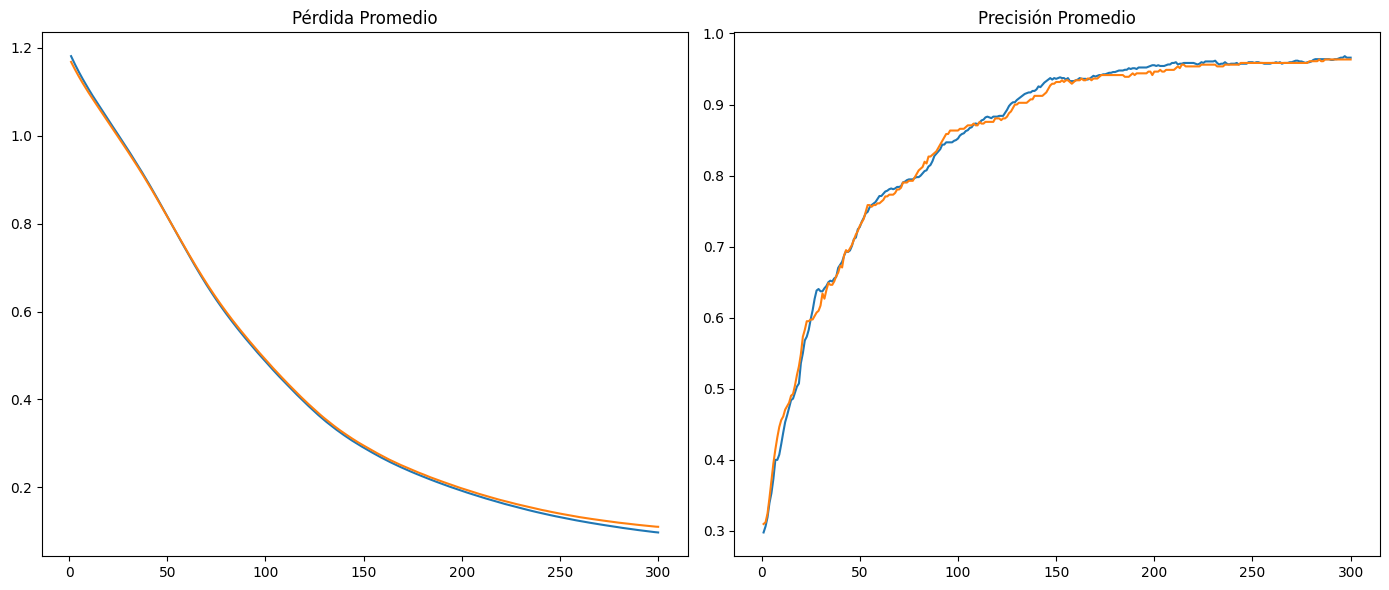

Grado 5: Pérdida Promedio = 0.1561, Precisión Promedio = 0.9400, Tiempo Promedio = 22.2668


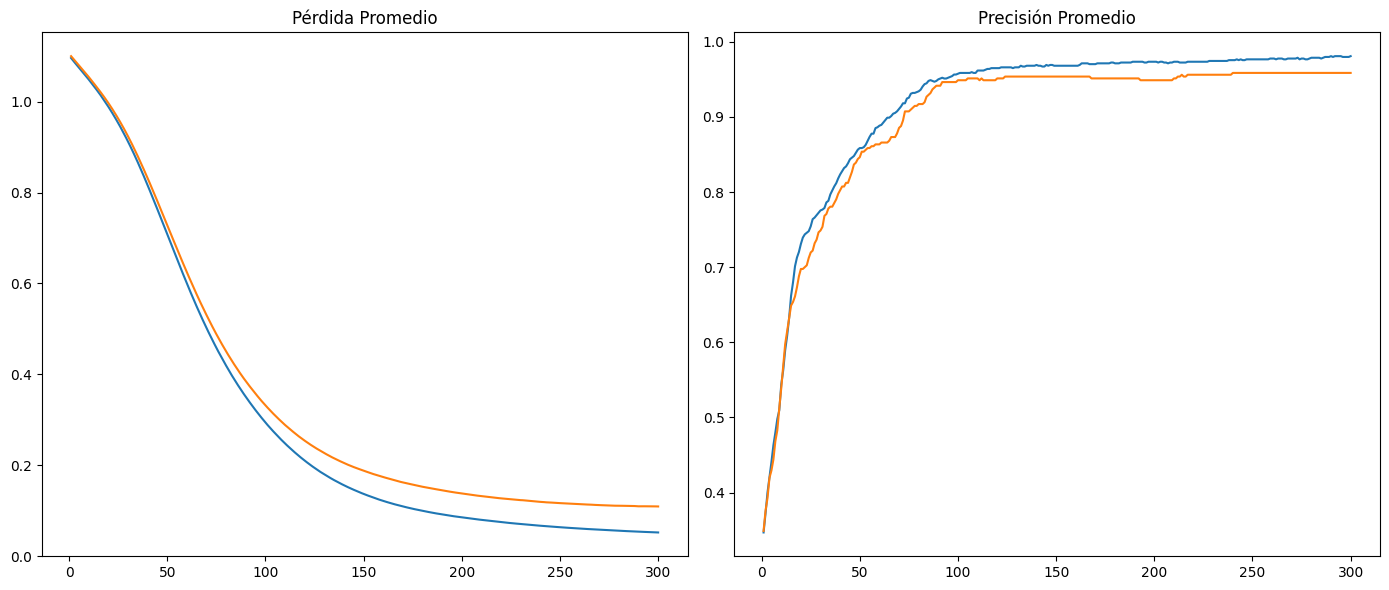

Grado 10: Pérdida Promedio = 0.3861, Precisión Promedio = 0.9267, Tiempo Promedio = 22.9947


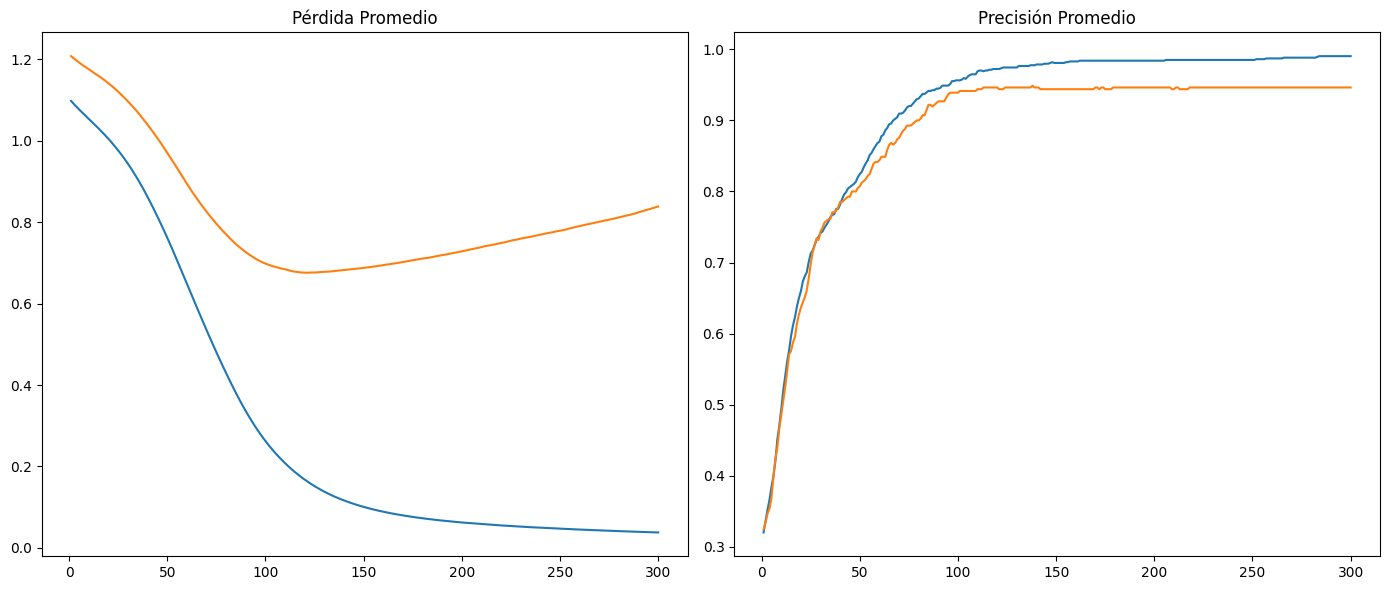

In [ ]:
print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Chebyshev)")
print("="*40)

scoreMean_cheb = {}
for deg in degrees:
    scoreMean_cheb[deg] = calculator(scores[deg], times[deg])
    print(f"Grado {deg}: Pérdida Promedio = {scoreMean_cheb[deg][0]:.4f}, Precisión Promedio = {scoreMean_cheb[deg][1]:.4f}, Tiempo Promedio = {scoreMean_cheb[deg][2]:.4f}")
    plot_cv_average_history(histories[deg])

In [ ]:
results = {deg: calculator(scores[deg], times[deg]) for deg in degrees}


# ===== CSV =====
os.makedirs("resultados", exist_ok=True)

data = []
for deg in degrees:
    loss, acc, t = results[deg]

    data.append({
        "Polinomio": "Shymaily",
        "Grado": deg,
        "Mejor_N": ,
        "Loss_Promedio": round(loss, 6),
        "Accuracy_Promedio": round(acc, 6),
        "Tiempo_Promedio(s)": round(t, 2)
    })

pd.DataFrame(data).to_csv("resultados/resultados_shymaily_Specialist.csv", index=False, sep=';')


# ===== GRÁFICAS =====
for deg in degrees:
    save_image_plot(histories[deg], deg)

print("Proceso finalizado correctamente")

Proceso finalizado correctamente
